In [1]:
# imports

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
pd.set_option('display.max_rows', 750)
pd.set_option('display.max_columns', 200)
pd.set_option('display.max_colwidth', None)

In [3]:
# extract load

In [4]:
ls -lh ./data

total 13G
-rw-r--r-- 1 mijka mijka 166M 10 août  17:20 clean_openfoodfacts_2.csv
-rw-r--r-- 1 mijka mijka 166M  3 août  17:36 clean_openfoodfacts.csv
-rw-r--r-- 1 mijka mijka 5,6G 22 avril 10:03 en.openfoodfacts.org.products.csv
-rw-r--r-- 1 mijka mijka 5,7G 22 avril 10:01 fr.openfoodfacts.org.products.csv
-rw-r--r-- 1 mijka mijka 809M 21 avril  2017 fr.openfoodfacts.org.products_old.csv


In [5]:
path = './data/'
csv_path = path + 'clean_openfoodfacts.csv'
df = pd.read_csv(csv_path, low_memory=False)

In [6]:
df.head()

,product_name,pnns_groups_1,pnns_groups_2,code,energy-kcal_100g,fat_100g,saturated-fat_100g,carbohydrates_100g,sugars_100g,proteins_100g,salt_100g,sodium_100g
0,jeunes pousses,unknown,unknown,00000000000000225,173.0,4.1,1.0,8.8,1.90,6.0,0.725,0.290598
1,L.casei,unknown,unknown,00000000000003429145,173.0,1.4,0.9,9.8,9.80,2.7,0.100,0.040000
2,Cacao,unknown,unknown,0000000000031,173.0,4.1,1.0,8.8,1.90,6.0,0.725,0.290598
3,Filetes de pollo empanado,unknown,unknown,000000000003327986,163.9,1.9,1.0,8.8,1.90,15.3,1.100,0.440000
4,Burger Meat Pollo,unknown,unknown,000000000004128579,194.0,11.0,3.9,5.7,0.05,18.0,0.725,0.290598


In [7]:
df.shape

(1708030, 12)

In [8]:
df.describe()

,energy-kcal_100g,fat_100g,saturated-fat_100g,carbohydrates_100g,sugars_100g,proteins_100g,salt_100g,sodium_100g
count,1.708030e+06,1.708030e+06,1.708030e+06,1.708030e+06,1.708030e+06,1.708030e+06,1.708030e+06,1.708030e+06
mean,1.944011e+02,8.390854e+00,2.918876e+00,1.540389e+01,4.218780e+00,8.406179e+00,1.105947e+00,4.580106e-01
std,1.363982e+02,1.161723e+01,5.271329e+00,1.903835e+01,7.153846e+00,9.301487e+00,2.347372e+00,1.263190e+00
min,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.000000e+02,1.300000e+00,2.000000e-01,3.570000e+00,6.000000e-01,2.200000e+00,1.900000e-01,7.600000e-02
50%,1.730000e+02,4.100000e+00,1.000000e+00,8.800000e+00,1.900000e+00,6.000000e+00,7.250000e-01,2.905983e-01
75%,2.610000e+02,1.000000e+01,2.700000e+00,1.666670e+01,4.000000e+00,1.100000e+01,1.160714e+00,4.666667e-01
max,8.995633e+02,9.999000e+01,9.990000e+01,9.996000e+01,9.990000e+01,9.990000e+01,7.142750e+01,9.398000e+01


In [9]:
#missing data
df.isnull().sum()

product_name          0
pnns_groups_1         0
pnns_groups_2         0
code                  0
energy-kcal_100g      0
fat_100g              0
saturated-fat_100g    0
carbohydrates_100g    0
sugars_100g           0
proteins_100g         0
salt_100g             0
sodium_100g           0
dtype: int64

# Univariate analysis

In [10]:
df.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1708030 entries, 0 to 1708029
Data columns (total 12 columns):
 #   Column              Dtype  
---  ------              -----  
 0   product_name        object 
 1   pnns_groups_1       object 
 2   pnns_groups_2       object 
 3   code                object 
 4   energy-kcal_100g    float64
 5   fat_100g            float64
 6   saturated-fat_100g  float64
 7   carbohydrates_100g  float64
 8   sugars_100g         float64
 9   proteins_100g       float64
 10  salt_100g           float64
 11  sodium_100g         float64
dtypes: float64(8), object(4)
memory usage: 156.4+ MB


## Numerical variables

In [11]:
df.columns[df.dtypes == 'float64']

Index(['energy-kcal_100g', 'fat_100g', 'saturated-fat_100g',
       'carbohydrates_100g', 'sugars_100g', 'proteins_100g', 'salt_100g',
       'sodium_100g'],
      dtype='object')

In [12]:
df.dtypes[df.dtypes == 'float64'].size

8

There's 8 numerical variables, that could be split into 2 groups regarding their different units of measurement / orders of magnitude :

- nutrients (less than 100g per 100g)
- energy (less than 900 Cal per 100g)

In [13]:
nutrients = ['fat_100g', 'saturated-fat_100g',
       'carbohydrates_100g', 'sugars_100g', 'proteins_100g', 'salt_100g',
       'sodium_100g']
energy = ['energy-kcal_100g']

##

fats = ['fat_100g', 'saturated-fat_100g']
sugars = ['carbohydrates_100g', 'sugars_100g']
other = ['proteins_100g', 'salt_100g',
       'sodium_100g']

In [14]:
def UVA_numeric(data, var_group):
  '''
  Univariate_Analysis_numeric
  takes a group of variables (INTEGER and FLOAT) and plot/print all the descriptives and properties along with KDE.

  Runs a loop: calculate all the descriptives of i(th) variable and plot/print it
  '''

  size = len(var_group)
  plt.figure(figsize = (7*size,3), dpi = 100)
  
  #looping for each variable
  for j,i in enumerate(var_group):
    
    # calculating descriptives of variable
    mini = data[i].min()
    maxi = data[i].max()
    ran = data[i].max()-data[i].min()
    mean = data[i].mean()
    median = data[i].median()
    st_dev = data[i].std()
    skew = data[i].skew()
    kurt = data[i].kurtosis()

    # calculating points of standard deviation
    points = mean-st_dev, mean+st_dev

    #Plotting the variable with every information
    plt.subplot(1,size,j+1)
    sns.kdeplot(data[i], shade=True)
    sns.lineplot(points, [0,0], color = 'black', label = "std_dev")
    sns.scatterplot([mini,maxi], [0,0], color = 'orange', label = "min/max")
    sns.scatterplot([mean], [0], color = 'red', label = "mean")
    sns.scatterplot([median], [0], color = 'blue', label = "median")
    plt.xlabel('{}'.format(i), fontsize = 20)
    plt.ylabel('density')
    plt.title('std_dev = {}; kurtosis = {};\nskew = {}; range = {}\nmean = {}; median = {}'.format((round(points[0],2),round(points[1],2)),
                                                                                                   round(kurt,2),
                                                                                                   round(skew,2),
                                                                                                   (round(mini,2),round(maxi,2),round(ran,2)),
                                                                                                   round(mean,2),
                                                                                                   round(median,2)))


[Text(0, 0, 'fat_100g'),
 Text(1, 0, 'saturated-fat_100g'),
 Text(2, 0, 'carbohydrates_100g'),
 Text(3, 0, 'sugars_100g'),
 Text(4, 0, 'proteins_100g'),
 Text(5, 0, 'salt_100g'),
 Text(6, 0, 'sodium_100g')]

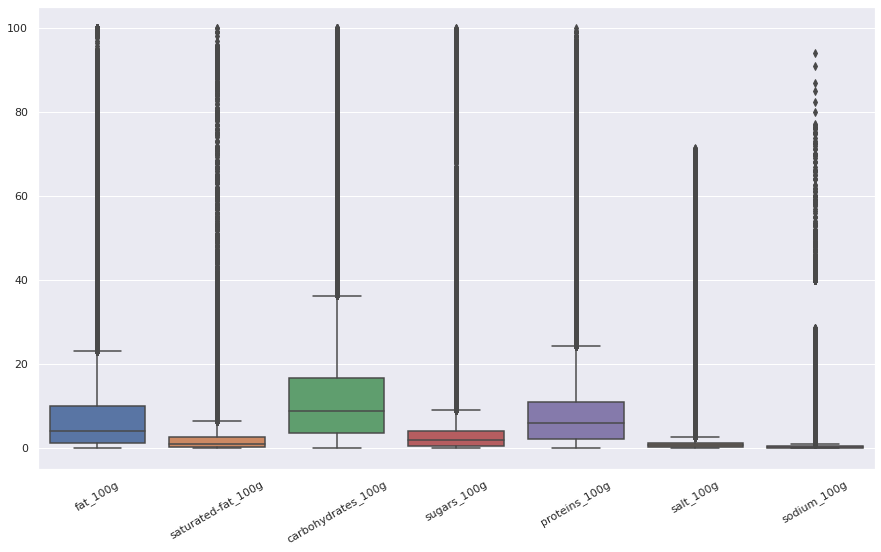

In [15]:
sns.set(rc={'figure.figsize':(15,8.5)})
ax = sns.boxplot(data=df[nutrients])
ax.set_xticklabels(ax.get_xticklabels(),rotation=30)

[Text(0, 0, 'energy-kcal_100g')]

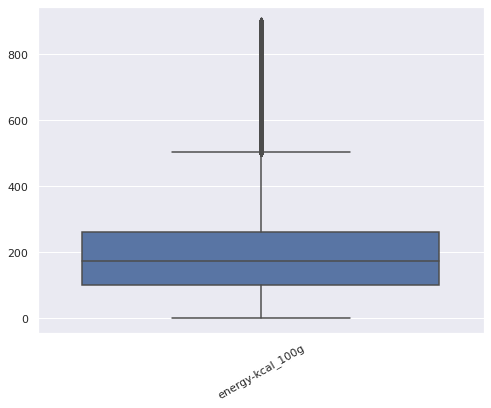

In [16]:
sns.set(rc={'figure.figsize':(8,6)})
ax = sns.boxplot(data=df[energy])
ax.set_xticklabels(ax.get_xticklabels(),rotation=30)

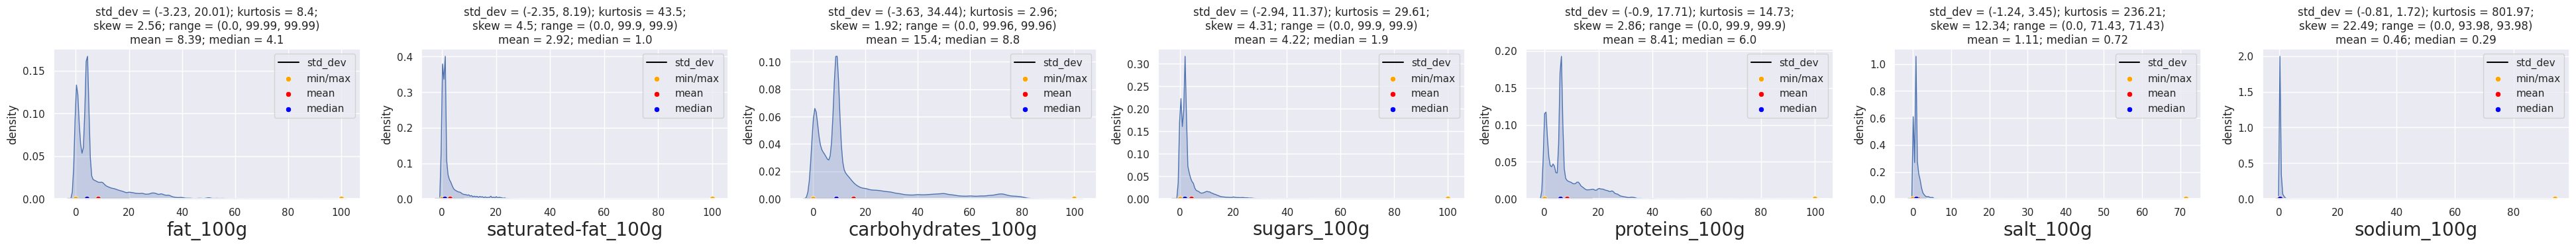

In [17]:
UVA_numeric(df,nutrients)

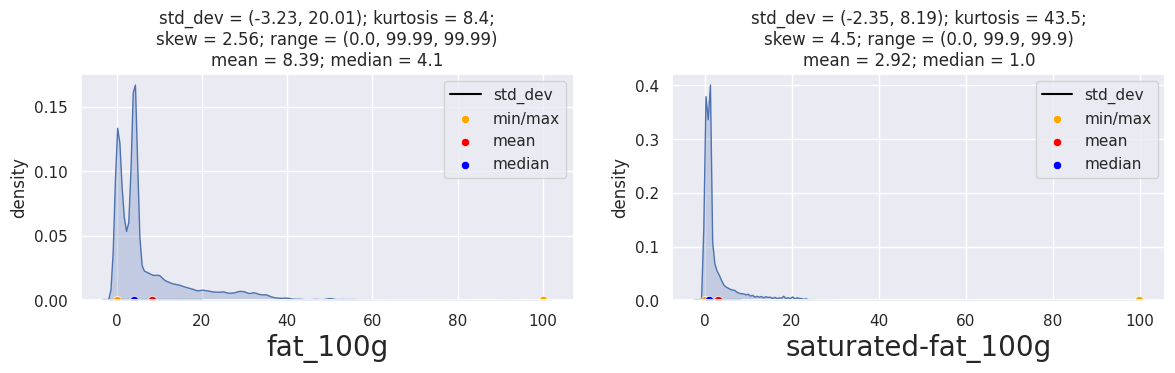

In [18]:
UVA_numeric(df,fats)

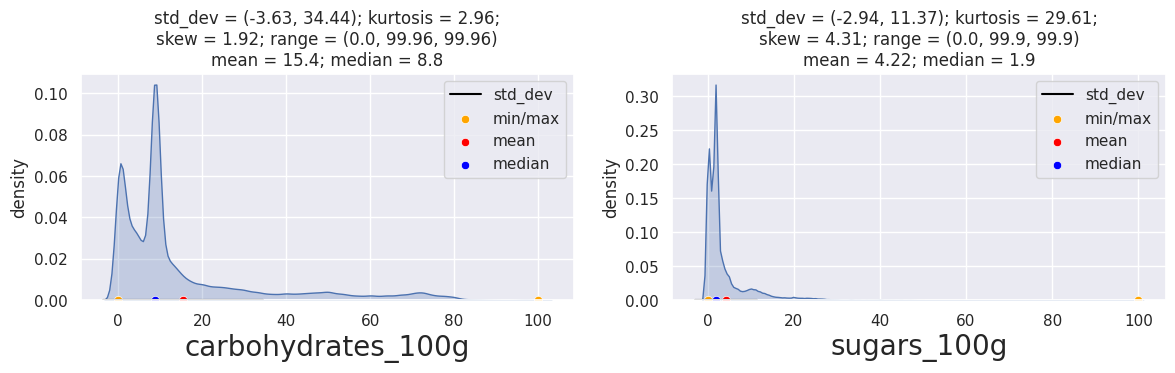

In [19]:
UVA_numeric(df,sugars)

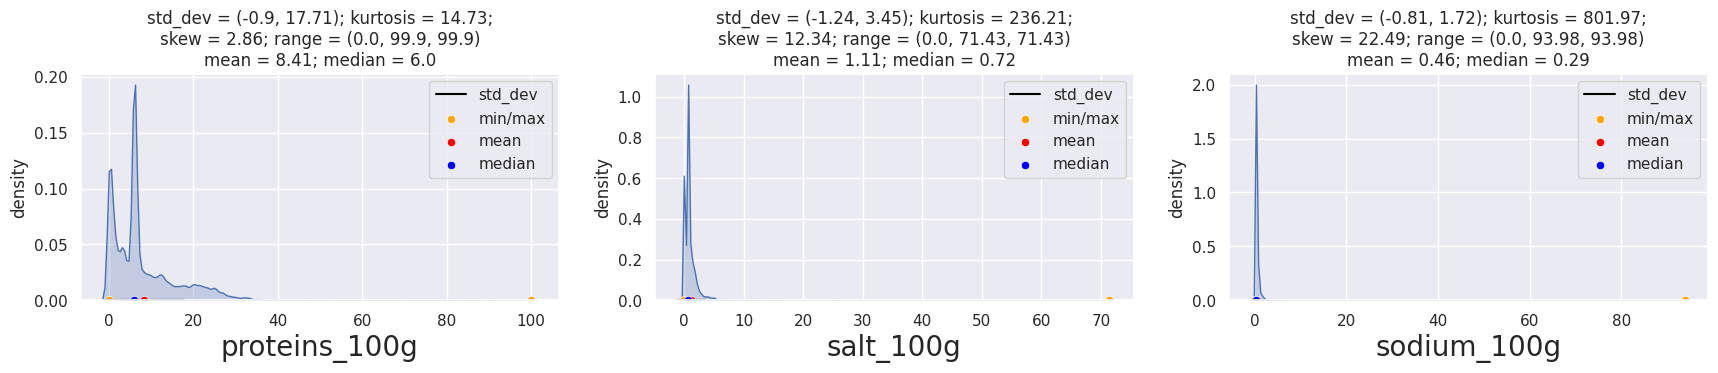

In [20]:
UVA_numeric(df,other)

## Categorical variables

In [21]:
cats = ['pnns_groups_1', 'pnns_groups_2']

In [22]:
# Custom function for easy visualisation of Categorical Variables
def UVA_category(data, var_group):

  '''
  Univariate_Analysis_categorical
  takes a group of variables (category) and plot/print all the value_counts and barplot.
  '''
  # setting figure_size
  size = len(var_group)
  plt.figure(figsize = (7*size,5), dpi = 100)

  # for every variable
  for j,i in enumerate(var_group):
    norm_count = data[i].value_counts(normalize = True)
    n_uni = data[i].nunique()

  #Plotting the variable with every information
    plt.subplot(1,size,j+1)
    sns.barplot(norm_count, norm_count.index , order = norm_count.index)
    plt.xlabel('fraction/percent', fontsize = 20)
    plt.ylabel('{}'.format(i), fontsize = 20)
    plt.title('n_uniques = {} \n value counts \n {};'.format(n_uni,norm_count))

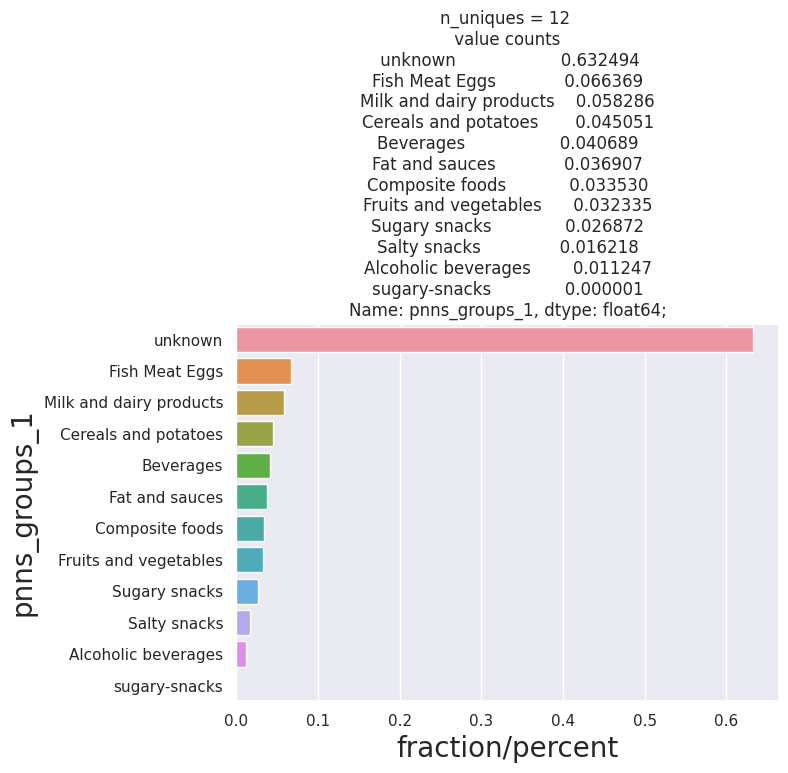

In [23]:
UVA_category(df, ['pnns_groups_1'])

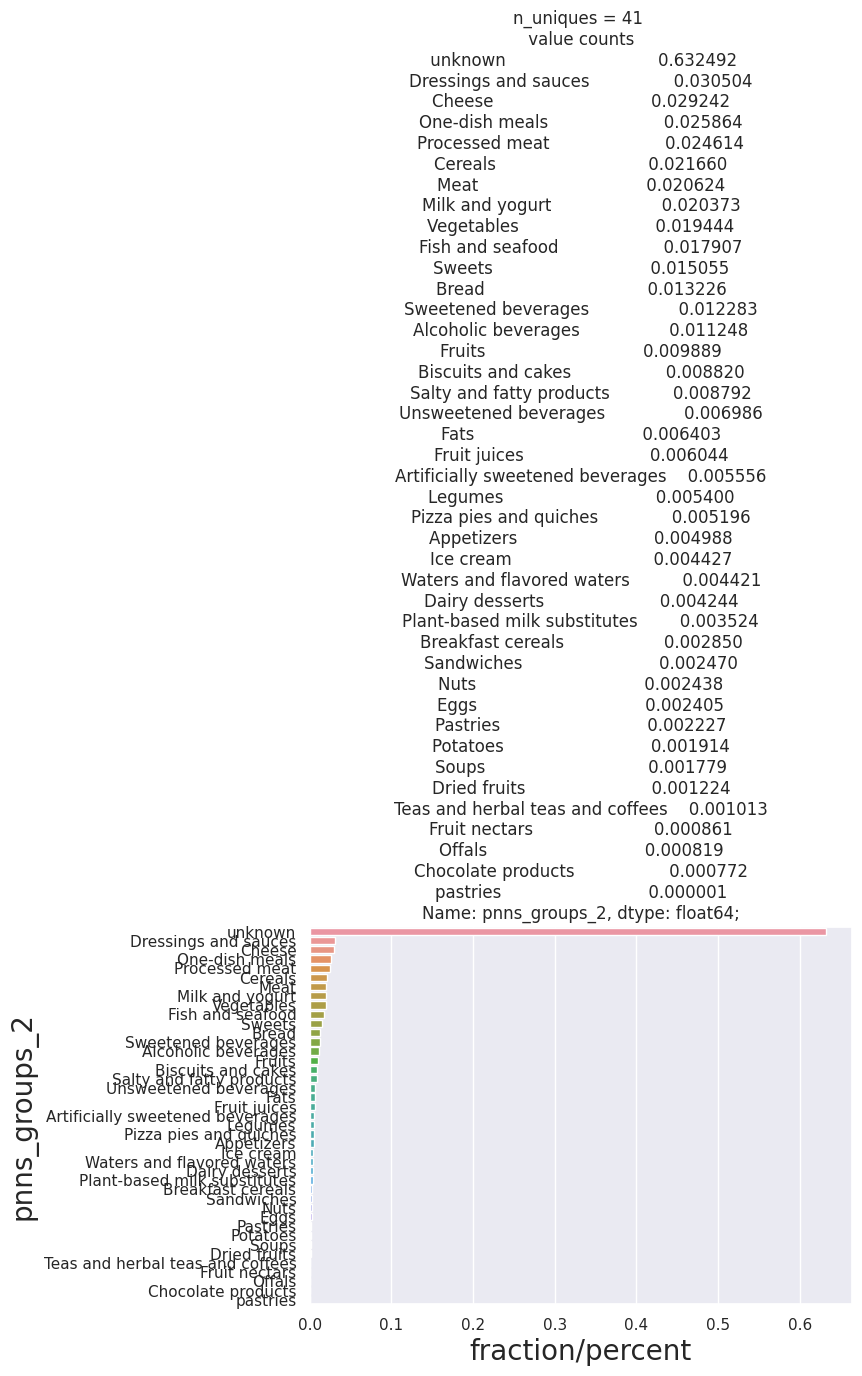

In [24]:
UVA_category(df, ['pnns_groups_2'])

In [ ]:
# scatter plate

# Multi-variate analysis

### PCA

In [25]:
features = df.columns[df.dtypes == 'float64']
features

Index(['energy-kcal_100g', 'fat_100g', 'saturated-fat_100g',
       'carbohydrates_100g', 'sugars_100g', 'proteins_100g', 'salt_100g',
       'sodium_100g'],
      dtype='object')

In [26]:
features.size

8

In [27]:
from sklearn.decomposition import PCA

pca = PCA(n_components=8)
pca.fit(X)

NameError: name 'X' is not defined

In [ ]:
# needing target aka nutriscore